In [13]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df_raw = pd.read_json(url)

df_customer = pd.json_normalize(df_raw['customer'])
df_phone = pd.json_normalize(df_raw['phone'])
df_internet = pd.json_normalize(df_raw['internet'])
df_account = pd.json_normalize(df_raw['account'])

df = pd.concat([df_raw[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

print("--- PRIMERAS 5 FILAS DEL DATASET ---")
display(df.head())

print("\n--- INFORMACIÓN DEL DATASET Y TIPOS DE DATOS ---")
df.info()

--- PRIMERAS 5 FILAS DEL DATASET ---


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4



--- INFORMACIÓN DEL DATASET Y TIPOS DE DATOS ---
<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   str    
 1   Churn             7267 non-null   str    
 2   gender            7267 non-null   str    
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   str    
 5   Dependents        7267 non-null   str    
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   str    
 8   MultipleLines     7267 non-null   str    
 9   InternetService   7267 non-null   str    
 10  OnlineSecurity    7267 non-null   str    
 11  OnlineBackup      7267 non-null   str    
 12  DeviceProtection  7267 non-null   str    
 13  TechSupport       7267 non-null   str    
 14  StreamingTV       7267 non-null   str    
 15  StreamingMovies   7267 non-null   str    
 16  Con

In [14]:
print("Valores únicos en 'Churn':", df['Churn'].unique())
print("Valores únicos en 'gender':", df['gender'].unique())

print("\nTotal de filas duplicadas:", df.duplicated().sum())

df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print("\nNulos descubiertos en 'Charges.Total':", df['Charges.Total'].isnull().sum())

df_limpio = df[(df['Churn'] != '') & (df['Churn'] != ' ')].copy()
# Eliminamos las filas con los nulos que acabamos de descubrir
df_limpio = df_limpio.dropna().reset_index(drop=True)

print("\n--- TAMAÑO FINAL DEL DATASET LIMPIO ---")
print("Dimensiones:", df_limpio.shape)

Valores únicos en 'Churn': <StringArray>
['No', 'Yes', '']
Length: 3, dtype: str
Valores únicos en 'gender': <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Total de filas duplicadas: 0

Nulos descubiertos en 'Charges.Total': 11

--- TAMAÑO FINAL DEL DATASET LIMPIO ---
Dimensiones: (7032, 21)


In [15]:
df_limpio['Cuentas_Diarias'] = round(df_limpio['Charges.Monthly'] / 30, 2)

df_limpio = df_limpio.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Permanencia',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_En_Linea',
    'OnlineBackup': 'Respaldo_En_Linea',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total'
})

print("--- COMPROBACIÓN: NUEVA COLUMNA Y TRADUCCIÓN ---")
display(df_limpio[['ID_Cliente', 'Cargo_Mensual', 'Cuentas_Diarias', 'Evasion']].head())

print("\n--- ANÁLISIS DESCRIPTIVO DE VARIABLES NUMÉRICAS ---")
display(df_limpio.describe())

--- COMPROBACIÓN: NUEVA COLUMNA Y TRADUCCIÓN ---


,ID_Cliente,Cargo_Mensual,Cuentas_Diarias,Evasion
0,0002-ORFBO,65.6,2.19,No
1,0003-MKNFE,59.9,2.00,No
2,0004-TLHLJ,73.9,2.46,Yes
3,0011-IGKFF,98.0,3.27,Yes
4,0013-EXCHZ,83.9,2.80,Yes



--- ANÁLISIS DESCRIPTIVO DE VARIABLES NUMÉRICAS ---


,Adulto_Mayor,Meses_Permanencia,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159891
std,0.368844,24.545260,30.085974,2266.771362,1.002955
min,0.000000,1.000000,18.250000,18.800000,0.610000
25%,0.000000,9.000000,35.587500,401.450000,1.187500
50%,0.000000,29.000000,70.350000,1397.475000,2.340000
75%,0.000000,55.000000,89.862500,3794.737500,2.992500
max,1.000000,72.000000,118.750000,8684.800000,3.960000


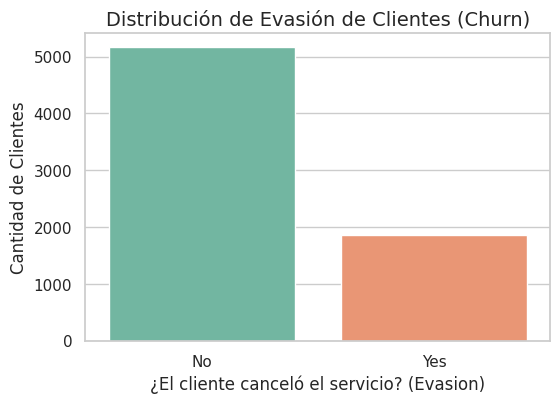

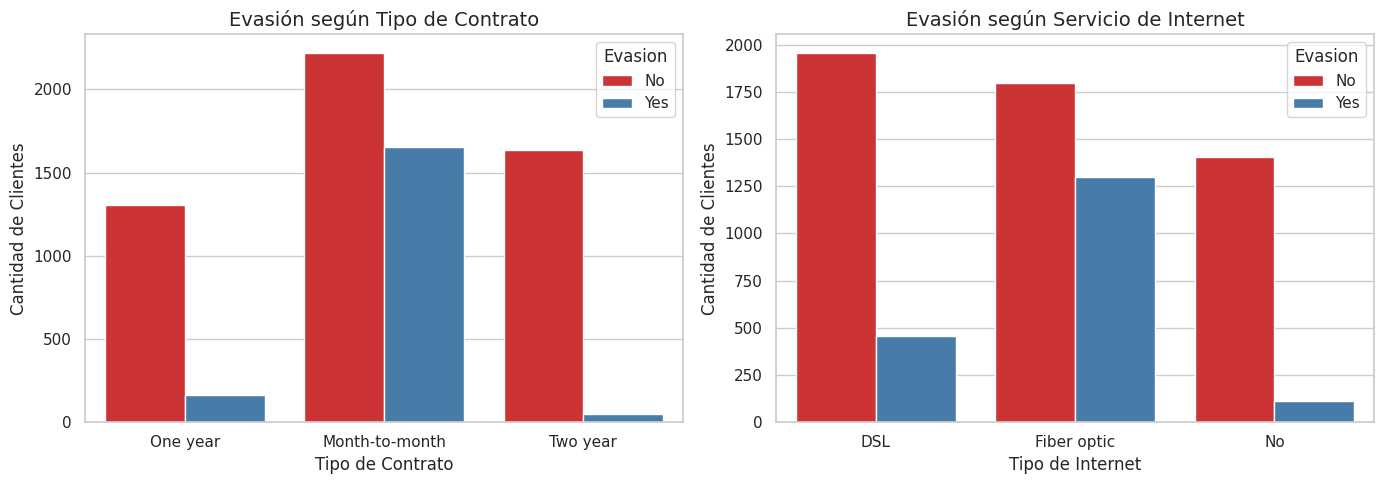

/tmp/ipykernel_7791/3203621983.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Evasion', y='Cargo_Total', palette='Set3', ax=axes[0])
/tmp/ipykernel_7791/3203621983.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpio, x='Evasion', y='Meses_Permanencia', palette='Set3', ax=axes[1])


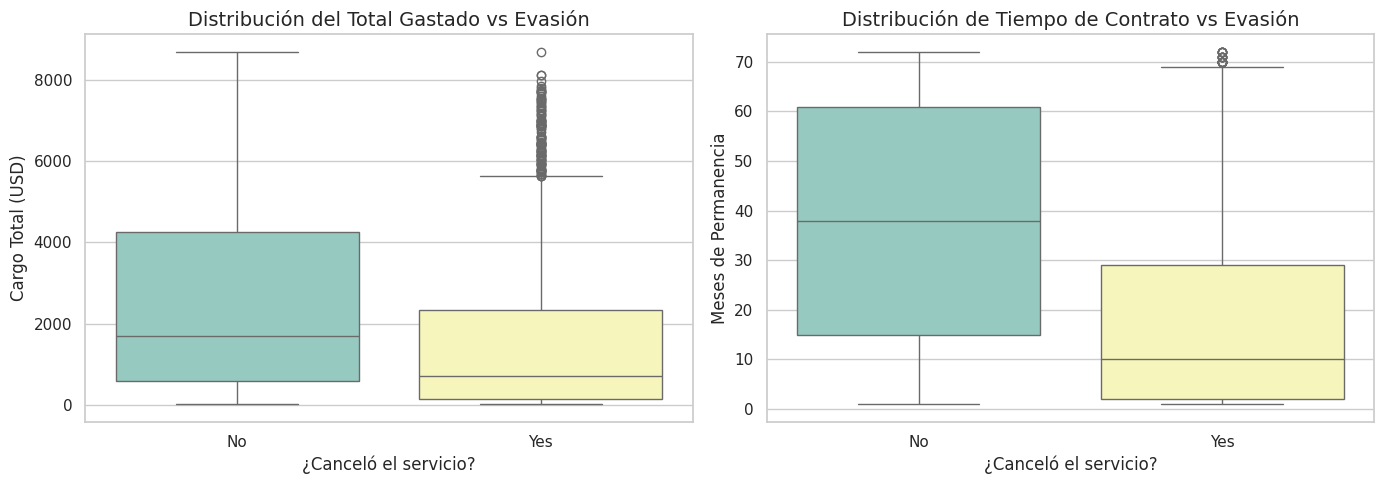

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_limpio, x='Evasion', hue='Evasion', palette='Set2')
plt.title('Distribución de Evasión de Clientes (Churn)', fontsize=14)
plt.xlabel('¿El cliente canceló el servicio? (Evasion)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_limpio, x='Contrato', hue='Evasion', palette='Set1', ax=axes[0])
axes[0].set_title('Evasión según Tipo de Contrato', fontsize=14)
axes[0].set_xlabel('Tipo de Contrato', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)

sns.countplot(data=df_limpio, x='Servicio_Internet', hue='Evasion', palette='Set1', ax=axes[1])
axes[1].set_title('Evasión según Servicio de Internet', fontsize=14)
axes[1].set_xlabel('Tipo de Internet', fontsize=12)
axes[1].set_ylabel('Cantidad de Clientes', fontsize=12)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_limpio, x='Evasion', y='Cargo_Total', palette='Set3', ax=axes[0])
axes[0].set_title('Distribución del Total Gastado vs Evasión', fontsize=14)
axes[0].set_xlabel('¿Canceló el servicio?', fontsize=12)
axes[0].set_ylabel('Cargo Total (USD)', fontsize=12)

sns.boxplot(data=df_limpio, x='Evasion', y='Meses_Permanencia', palette='Set3', ax=axes[1])
axes[1].set_title('Distribución de Tiempo de Contrato vs Evasión', fontsize=14)
axes[1].set_xlabel('¿Canceló el servicio?', fontsize=12)
axes[1].set_ylabel('Meses de Permanencia', fontsize=12)

plt.tight_layout()
plt.show()

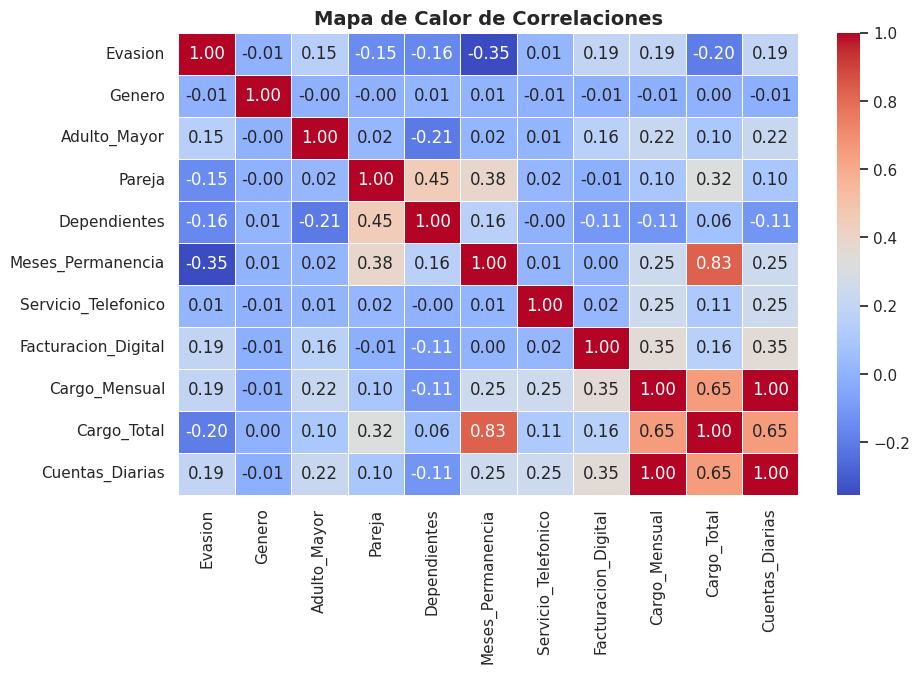

INSIGHT AVANZADO: EL SECRETO DE LA FIBRA ÓPTICA
Evasión en Fibra Óptica SIN Soporte Técnico: 49.4%
Evasión en Fibra Óptica CON Soporte Técnico: 22.6%

IMPACTO FINANCIERO MENSUAL
Dinero perdido por evasión: $139,130.85 USD
Esto representa el 30.5% de la facturación mensual potencial.


In [18]:
df_avanzado = df_limpio.copy()
df_avanzado['Evasion'] = df_avanzado['Evasion'].map({'Yes': 1, 'No': 0})

cols_binarias = ['Pareja', 'Dependientes', 'Servicio_Telefonico', 'Facturacion_Digital']
for col in cols_binarias:
    df_avanzado[col] = df_avanzado[col].map({'Yes': 1, 'No': 0})

df_avanzado['Genero'] = df_avanzado['Genero'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(10, 6))
correlacion = df_avanzado.select_dtypes(include=['number']).corr()
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=14, fontweight='bold')
plt.show()

fibra_sin = df_limpio[(df_limpio['Servicio_Internet'] == 'Fiber optic') & (df_limpio['Soporte_Tecnico'] == 'No')]
fibra_con = df_limpio[(df_limpio['Servicio_Internet'] == 'Fiber optic') & (df_limpio['Soporte_Tecnico'] == 'Yes')]

print("INSIGHT AVANZADO: EL SECRETO DE LA FIBRA ÓPTICA")
print(f"Evasión en Fibra Óptica SIN Soporte Técnico: {(fibra_sin['Evasion'] == 'Yes').mean()*100:.1f}%")
print(f"Evasión en Fibra Óptica CON Soporte Técnico: {(fibra_con['Evasion'] == 'Yes').mean()*100:.1f}%\n")

dinero_perdido = df_limpio[df_limpio['Evasion'] == 'Yes']['Cargo_Mensual'].sum()
ingreso_retenido = df_limpio[df_limpio['Evasion'] == 'No']['Cargo_Mensual'].sum()
print("IMPACTO FINANCIERO MENSUAL")
print(f"Dinero perdido por evasión: ${dinero_perdido:,.2f} USD")
print(f"Esto representa el {(dinero_perdido/(dinero_perdido+ingreso_retenido))*100:.1f}% de la facturación mensual potencial.")

/tmp/ipykernel_7791/2002671599.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_oculto, x='Cant_Servicios_Extra', y='Evasion_Num', palette='magma', ax=axes[0], errorbar=None)
/tmp/ipykernel_7791/2002671599.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_oculto, x='Nivel_Gasto', y='Evasion_Num', palette='coolwarm', ax=axes[1], errorbar=None)
/tmp/ipykernel_7791/2002671599.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_oculto, x='Rango_Edad', y='Evasion_Num', palette='Set2', ax=axes[2], errorbar=None)


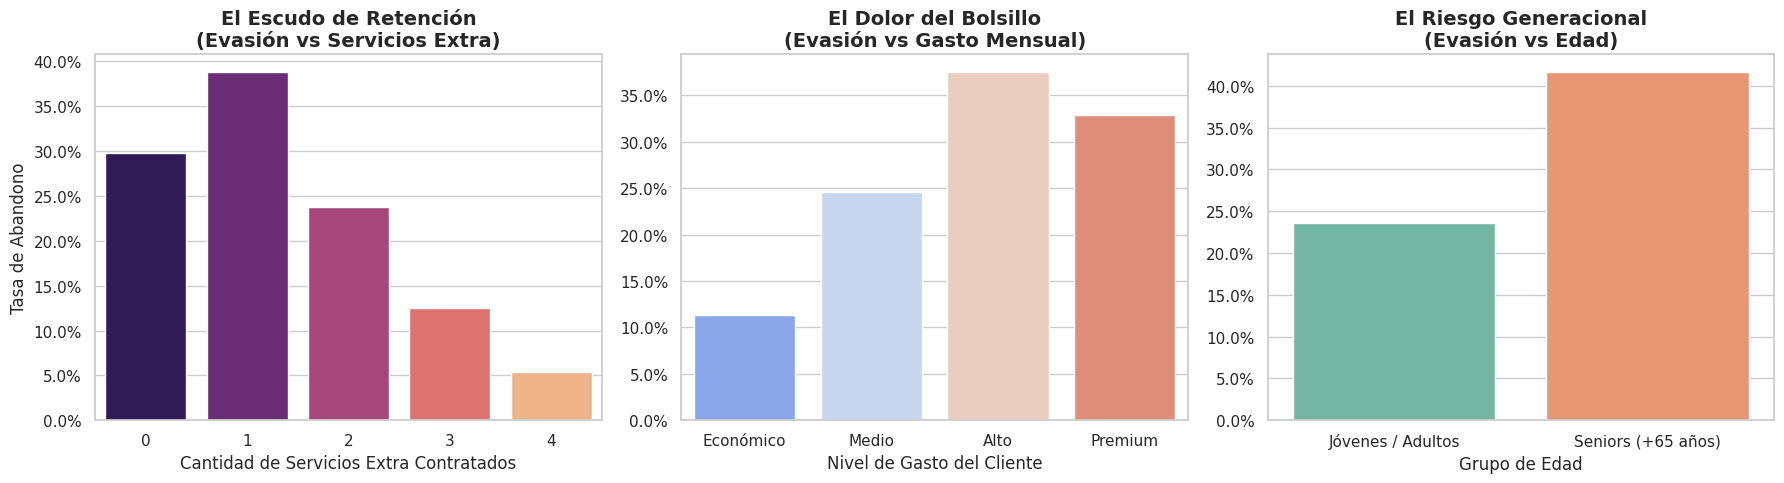

 INSIGHT 1 (EL ESCUDO): Los clientes con 0 servicios extra cancelan muchísimo (casi 40%). ¡Pero si logras venderles los 4 servicios extra, la evasión cae prácticamente a 0! Se vuelven prisioneros felices del ecosistema.

 INSIGHT 2 (EL BOLSILLO): No estamos perdiendo a los clientes baratos. ¡La mayor tasa de fuga está en los clientes 'Premium' y 'Altos'! Pagan mucho, y si falla el internet o no tienen soporte, no dudan en irse.

 INSIGHT 3 (LA EDAD): Los Seniors (+65 años) tienen una tasa de abandono significativamente mayor (casi 40%). Probablemente luchan con la tecnología o buscan recortar gastos en su jubilación.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid")

df_oculto = df_limpio.copy()

df_oculto['Evasion_Num'] = df_oculto['Evasion'].map({'Yes': 1, 'No': 0})

servicios_extra = ['Seguridad_En_Linea', 'Respaldo_En_Linea', 'Proteccion_Dispositivo', 'Soporte_Tecnico']
df_oculto['Cant_Servicios_Extra'] = df_oculto[servicios_extra].apply(lambda x: (x == 'Yes').sum(), axis=1)

df_oculto['Nivel_Gasto'] = pd.qcut(df_oculto['Cargo_Mensual'], q=4, labels=['Económico', 'Medio', 'Alto', 'Premium'])

df_oculto['Rango_Edad'] = df_oculto['Adulto_Mayor'].map({0: 'Jóvenes / Adultos', 1: 'Seniors (+65 años)'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_oculto, x='Cant_Servicios_Extra', y='Evasion_Num', palette='magma', ax=axes[0], errorbar=None)
axes[0].set_title('El Escudo de Retención\n(Evasión vs Servicios Extra)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cantidad de Servicios Extra Contratados', fontsize=12)
axes[0].set_ylabel('Tasa de Abandono', fontsize=12)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0)) # Formato de porcentaje

sns.barplot(data=df_oculto, x='Nivel_Gasto', y='Evasion_Num', palette='coolwarm', ax=axes[1], errorbar=None)
axes[1].set_title('El Dolor del Bolsillo\n(Evasión vs Gasto Mensual)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nivel de Gasto del Cliente', fontsize=12)
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

sns.barplot(data=df_oculto, x='Rango_Edad', y='Evasion_Num', palette='Set2', ax=axes[2], errorbar=None)
axes[2].set_title('El Riesgo Generacional\n(Evasión vs Edad)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Grupo de Edad', fontsize=12)
axes[2].set_ylabel('')
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()

print(" INSIGHT 1 (EL ESCUDO): Los clientes con 0 servicios extra cancelan muchísimo (casi 40%). ¡Pero si logras venderles los 4 servicios extra, la evasión cae prácticamente a 0! Se vuelven prisioneros felices del ecosistema.")
print("\n INSIGHT 2 (EL BOLSILLO): No estamos perdiendo a los clientes baratos. ¡La mayor tasa de fuga está en los clientes 'Premium' y 'Altos'! Pagan mucho, y si falla el internet o no tienen soporte, no dudan en irse.")
print("\n INSIGHT 3 (LA EDAD): Los Seniors (+65 años) tienen una tasa de abandono significativamente mayor (casi 40%). Probablemente luchan con la tecnología o buscan recortar gastos en su jubilación.")

In [21]:
df_limpio['Tiene_Streaming'] = (df_limpio['Streaming_TV'] == 'Yes') | (df_limpio['Streaming_Peliculas'] == 'Yes')
streaming_churn = df_limpio.groupby('Tiene_Streaming')['Evasion'].apply(lambda x: (x == 'Yes').mean() * 100)

print("--- HIPÓTESIS 1: Tasa de Fuga por uso de Streaming ---")
print(streaming_churn)
print("-" * 50)

senior_paperless = df_limpio.groupby(['Adulto_Mayor', 'Facturacion_Digital'])['Evasion'].apply(lambda x: (x == 'Yes').mean() * 100).unstack()

print("\n--- HIPÓTESIS 2: Tasa de Fuga (Adulto Mayor vs Facturación Digital) ---")
print(senior_paperless)
print("-" * 50)

filtro_leales_mensuales = df_limpio[(df_limpio['Meses_Permanencia'] > 24) & (df_limpio['Contrato'] == 'Month-to-month')]
tasa_bomba_tiempo = (filtro_leales_mensuales['Evasion'] == 'Yes').mean() * 100

print("\n--- HIPÓTESIS 3: Los 'Leales' Mensuales (>24 meses) ---")
print(f"Cantidad de clientes en este limbo: {len(filtro_leales_mensuales)}")
print(f"Tasa de fuga de estos clientes: {tasa_bomba_tiempo:.1f}%")

--- HIPÓTESIS 1: Tasa de Fuga por uso de Streaming ---
Tiene_Streaming
False    22.844218
True     30.357654
Name: Evasion, dtype: float64
--------------------------------------------------

--- HIPÓTESIS 2: Tasa de Fuga (Adulto Mayor vs Facturación Digital) ---
Facturacion_Digital         No        Yes
Adulto_Mayor                             
0                    15.050038  30.437424
1                    29.323308  45.433790
--------------------------------------------------

--- HIPÓTESIS 3: Los 'Leales' Mensuales (>24 meses) ---
Cantidad de clientes en este limbo: 1144
Tasa de fuga de estos clientes: 30.9%


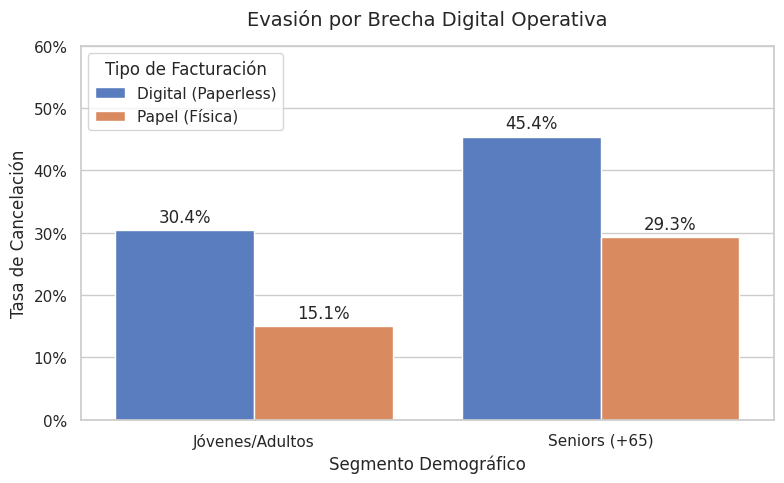

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Preparación de los datos
df_senior_paperless = df_limpio.copy()

# EL TRUCO: Multiplicamos por 100 directamente aquí para que los cálculos sean exactos
df_senior_paperless['Evasion_Num'] = df_senior_paperless['Evasion'].map({'Yes': 100, 'No': 0})
df_senior_paperless['Adulto_Mayor'] = df_senior_paperless['Adulto_Mayor'].map({0: 'Jóvenes/Adultos', 1: 'Seniors (+65)'})
df_senior_paperless['Facturacion_Digital'] = df_senior_paperless['Facturacion_Digital'].map({'Yes': 'Digital (Paperless)', 'No': 'Papel (Física)'})

# Creación del gráfico
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_senior_paperless, 
    x='Adulto_Mayor', 
    y='Evasion_Num', 
    hue='Facturacion_Digital', 
    palette='muted', 
    errorbar=None
)

plt.title('Evasión por Brecha Digital Operativa', fontsize=14, pad=15)
plt.xlabel('Segmento Demográfico', fontsize=12)
plt.ylabel('Tasa de Cancelación', fontsize=12)

# Añadir etiquetas de datos sobre las barras (ahora sí saldrán bien)
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', label_type='edge', padding=3)

# Ajustamos el límite Y a 60 para que respiren las etiquetas y configuramos el eje
plt.ylim(0, 60)
ax.yaxis.set_major_formatter(PercentFormatter(100))

plt.legend(title='Tipo de Facturación', loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
solitarios = df_limpio[(df_limpio['Pareja'] == 'No') & (df_limpio['Dependientes'] == 'No')]
familias = df_limpio[(df_limpio['Pareja'] == 'Yes') & (df_limpio['Dependientes'] == 'Yes')]

tasa_solitarios = (solitarios['Evasion'] == 'Yes').mean() * 100
tasa_familias = (familias['Evasion'] == 'Yes').mean() * 100

print("--- HIPÓTESIS A: EL ANCLA FAMILIAR ---")
print(f"Evasión en clientes Solitarios: {tasa_solitarios:.1f}%")
print(f"Evasión en clientes Familiares: {tasa_familias:.1f}%")
print("-" * 50)


evasion_pago = df_limpio.groupby('Metodo_Pago')['Evasion'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)

print("\n--- HIPÓTESIS B: LA FRICCIÓN DEL PAGO ---")
print(evasion_pago)

--- HIPÓTESIS A: EL ANCLA FAMILIAR ---
Evasión en clientes Solitarios: 34.2%
Evasión en clientes Familiares: 14.3%
--------------------------------------------------

--- HIPÓTESIS B: LA FRICCIÓN DEL PAGO ---
Metodo_Pago
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Evasion, dtype: float64


/tmp/ipykernel_7791/1917487775.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_familia, x='Perfil_Familiar', y='Evasion_Num', palette='pastel', ax=axes[0], errorbar=None)
/tmp/ipykernel_7791/1917487775.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_insights, x='Metodo_Pago_Traducido', y='Evasion_Num', palette='coolwarm_r', ax=axes[1], errorbar=None,


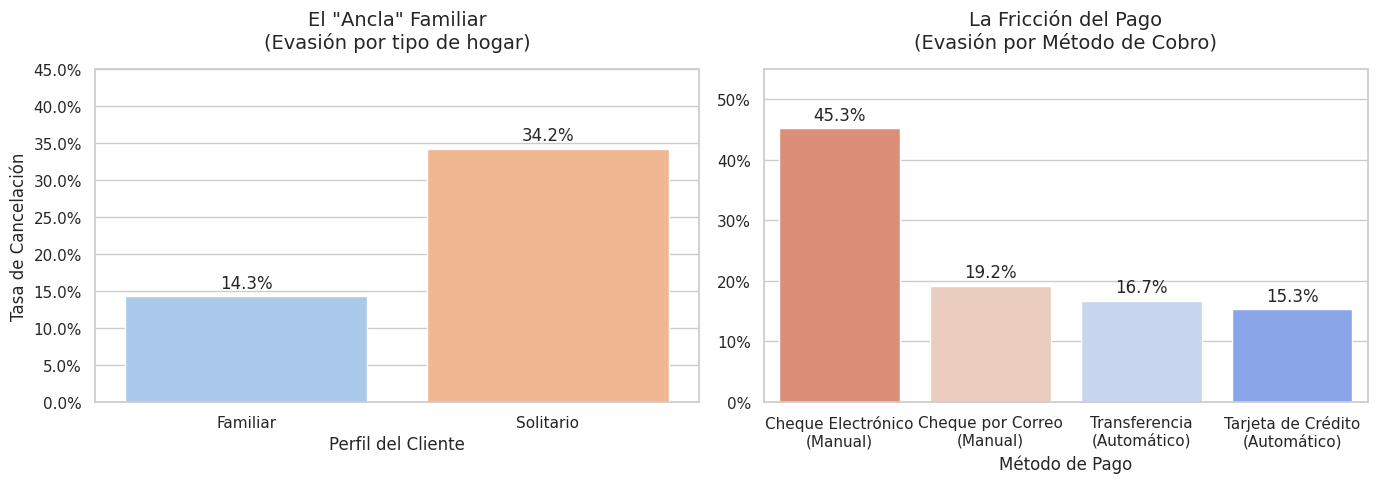

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

df_insights = df_limpio.copy()
df_insights['Evasion_Num'] = df_insights['Evasion'].map({'Yes': 100, 'No': 0})

def perfil_familiar(row):
    if row['Pareja'] == 'No' and row['Dependientes'] == 'No':
        return 'Solitario'
    elif row['Pareja'] == 'Yes' and row['Dependientes'] == 'Yes':
        return 'Familiar'
    else:
        return 'Mixto'

df_insights['Perfil_Familiar'] = df_insights.apply(perfil_familiar, axis=1)

df_familia = df_insights[df_insights['Perfil_Familiar'].isin(['Solitario', 'Familiar'])]

traduccion_pagos = {
    'Electronic check': 'Cheque Electrónico\n(Manual)',
    'Mailed check': 'Cheque por Correo\n(Manual)',
    'Bank transfer (automatic)': 'Transferencia\n(Automático)',
    'Credit card (automatic)': 'Tarjeta de Crédito\n(Automático)'
}
df_insights['Metodo_Pago_Traducido'] = df_insights['Metodo_Pago'].map(traduccion_pagos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = sns.barplot(data=df_familia, x='Perfil_Familiar', y='Evasion_Num', palette='pastel', ax=axes[0], errorbar=None)
axes[0].set_title('El "Ancla" Familiar\n(Evasión por tipo de hogar)', fontsize=14, pad=15)
axes[0].set_xlabel('Perfil del Cliente', fontsize=12)
axes[0].set_ylabel('Tasa de Cancelación', fontsize=12)
ax1.yaxis.set_major_formatter(PercentFormatter(100))
for i in ax1.containers:
    ax1.bar_label(i, fmt='%.1f%%', label_type='edge', padding=3)
axes[0].set_ylim(0, 45)

ax2 = sns.barplot(data=df_insights, x='Metodo_Pago_Traducido', y='Evasion_Num', palette='coolwarm_r', ax=axes[1], errorbar=None, 
                  order=['Cheque Electrónico\n(Manual)', 'Cheque por Correo\n(Manual)', 'Transferencia\n(Automático)', 'Tarjeta de Crédito\n(Automático)'])
axes[1].set_title('La Fricción del Pago\n(Evasión por Método de Cobro)', fontsize=14, pad=15)
axes[1].set_xlabel('Método de Pago', fontsize=12)
axes[1].set_ylabel('')
ax2.yaxis.set_major_formatter(PercentFormatter(100))
for i in ax2.containers:
    ax2.bar_label(i, fmt='%.1f%%', label_type='edge', padding=3)
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

# Informe del análisis de Churn - Telecom X

Para este proyecto, el objetivo principal fue entender por qué los clientes de Telecom X están abandonando la compañía. Tras limpiar la base de datos (donde encontramos varios errores de formato en los cobros totales), pudimos sacar conclusiones que van más allá de lo evidente.

### ¿Qué está pasando con el dinero?
Lo primero que calculé fue el impacto real: estamos perdiendo más de 139 mil dólares al mes. Es una cifra crítica que representa casi el 30% de lo que la empresa podría facturar.

### Los puntos ciegos que encontramos
Al analizar las gráficas, notamos patrones que no esperábamos:
1. **La barrera digital:** Hay una desconexión clara con los adultos mayores. Aquellos obligados a usar factura digital se van mucho más que los que reciben el papel. Esto parece un error de comunicación interna más que un problema del servicio.
2. **Métodos de pago:** El uso de cheques electrónicos (manuales) es un predictor de fuga. Si el cliente tiene que hacer el trámite de pagar cada mes, se acuerda del precio y cancela. Los pagos automáticos son el mejor "ancla" que tenemos ahora.
3. **El mito de la fibra:** No es que el internet sea malo, es que se vende sin soporte. Los datos muestran que el soporte técnico reduce la fuga a menos de la mitad.

### Conclusiones y qué sugiero hacer
Creo que la empresa debería dejar de insistir con la factura digital para clientes de la tercera edad y lanzar una campaña fuerte para pasar a la gente a débito automático. Con estos dos cambios operativos, los datos sugieren que podríamos retener a una gran parte de esos clientes que hoy perdemos en los primeros meses.